# Mixed Precision Performance Analysis: FP32 vs FP16 vs BF16 for Deep Learning Workloads Using PyTorch

**Course:** CS705 — Accelerated Computing  
**Project Type:** Final Project (Accelerated Computing / Performance Analysis)

**Team (9 members):**

| #   | Roll No. | Name                 | Section                                             |
| --- | -------- | -------------------- | --------------------------------------------------- |
| 1   | Member 1 | Nadi Myint Than      | Introduction, Problem Statement, Objectives         |
| 2   | Member 2 | Thi Han Soe          | Research Questions, Hypotheses, Benchmarking Method |
| 3   | Member 3 | Phyo Zaw Linn        | Background Theory (Floating Point, CUDA, AMP)       |
| 4   | Member 4 | Wai Yan Htut         | Experiment 1 — Matrix Multiplication                |
| 5   | Member 5 | Phyoe Thiha          | Experiment 2 — Element-wise & Reduction Operations  |
| 6   | Member 6 | Ye Zaw Htet          | Experiment 3 — CNN Training with AMP                |
| 7   | Member 7 | Myint Myat Pyae Sone | Experiment 4 — Memory & Throughput Analysis         |
| 8   | Member 8 | Wai Yan Tun          | Statistical Analysis & Cross-Experiment Comparison  |
| 9   | Member 9 | Zar Ni Hein          | Results, RQ/H Answers, Limitations, Conclusion      |


## 1. Introduction

Modern deep learning workloads are computationally demanding. Traditionally, PyTorch operates in 32-bit floating point (FP32), which provides high numerical precision but consumes significant memory bandwidth and compute resources. With the advent of Tensor Cores on NVIDIA GPUs (introduced with the Volta architecture and improved in Turing, Ampere, and Hopper generations), two lower-precision formats have become practical for training and inference: **FP16** (IEEE 754 half-precision, 16-bit) and **BF16** (Brain Float 16, a Google-developed format also at 16 bits but with a wider exponent range than FP16).

This project systematically benchmarks **FP32 vs FP16 vs BF16** across four workload categories — matrix multiplication, element-wise and reduction operations, CNN training via PyTorch's Automatic Mixed Precision (AMP), and memory/throughput profiling — to determine when and by how much lower-precision formats accelerate computation, and what numerical trade-offs they introduce.

This is an **accelerated-computing performance study**, not a machine-learning accuracy study. Where accuracy or loss values appear (e.g. CNN training), they serve only as a correctness sanity check — the primary measurement is always _time_ and _throughput_.


## 2. Background Theory

### 2.1 Floating-Point Representations

A floating-point number is stored as a sign bit, a biased exponent, and a mantissa (significand). The key formats in this project differ as follows:

| Format   | Total bits | Sign | Exponent | Mantissa | Approx. max value | Notes                                                                                   |
| -------- | ---------- | ---- | -------- | -------- | ----------------- | --------------------------------------------------------------------------------------- |
| **FP32** | 32         | 1    | 8        | 23       | ~3.4 × 10³⁸       | IEEE 754 single precision; default PyTorch dtype                                        |
| **FP16** | 16         | 1    | 5        | 10       | ~65504            | IEEE 754 half precision; narrow dynamic range; prone to overflow/underflow              |
| **BF16** | 16         | 1    | 8        | 7        | ~3.4 × 10³⁸       | Same exponent range as FP32; less mantissa precision; more numerically stable than FP16 |

### 2.2 Why Lower Precision Can Be Faster

Lower-precision formats offer two hardware advantages:

1. **Memory bandwidth** — a 16-bit value occupies half the memory of a 32-bit value, so twice as many values fit in a cache line, register file, or memory transaction. This directly reduces data-movement bottlenecks in memory-bandwidth-bound kernels.
2. **Tensor Core throughput** — NVIDIA Tensor Cores are matrix-multiply-accumulate units designed specifically for 16-bit inputs. On an A100 GPU, peak FP16/BF16 Tensor Core throughput is 312 TFLOPS compared to 77 TFLOPS for standard FP32 CUDA cores — roughly 4× the theoretical peak.

### 2.3 FP16 Numerical Instability and Loss Scaling

FP16's narrow exponent range (max ~65504) means gradients can overflow (become `inf`) or underflow (become zero) during backpropagation, destabilizing training. PyTorch's **GradScaler** addresses this by multiplying the loss by a large scale factor before the backward pass, scaling gradients into the representable FP16 range, then dividing the gradients back before the optimizer step. BF16 avoids this problem because it shares FP32's exponent width.

### 2.4 Automatic Mixed Precision (AMP)

PyTorch's `torch.autocast` context manager implements **Automatic Mixed Precision**: it automatically selects FP16 or BF16 for operations that benefit (matrix multiplications, convolutions) and keeps FP32 for operations where precision matters (reductions, softmax, loss computation). This gives most of the speed benefit of lower precision with minimal manual code changes and reduced risk of numerical instability.

### 2.5 CUDA and Tensor Cores

CUDA (Compute Unified Device Architecture) is NVIDIA's parallel-computing platform. Tensor Cores, introduced in Volta GPUs, are specialized execution units that perform a 4×4 matrix-multiply-accumulate in a single clock cycle using 16-bit inputs and 32-bit accumulation. PyTorch's `torch.matmul` and `nn.Conv2d` automatically dispatch to Tensor Cores when the inputs are FP16 or BF16 on a compatible GPU.

### 2.6 PyTorch dtype System

In PyTorch, every tensor has a `dtype` attribute (`torch.float32`, `torch.float16`, `torch.bfloat16`, etc.). Casting a tensor to a lower precision is done with `tensor.to(dtype)` or `tensor.half()` / `tensor.bfloat16()`. Operations on mixed-dtype tensors follow PyTorch's type promotion rules, so explicit casting is generally required for controlled benchmarking.

### 2.7 Memory Bandwidth vs Compute Bound

An operation is **memory-bandwidth bound** when the bottleneck is reading/writing data, not performing arithmetic (e.g. element-wise operations on large tensors). It is **compute bound** when arithmetic dominates (e.g. large matrix multiplications with high arithmetic intensity). Lower precision helps both cases, but the _degree_ of speedup differs: bandwidth-bound ops see roughly 2× speedup from halving the data width; compute-bound ops on Tensor Core hardware can see 4× or more.


## 3. Problem Statement

Many practitioners default to FP32 out of habit or caution, or switch wholesale to FP16 without understanding the numerical risks. BF16 is newer and less widely understood despite being available on NVIDIA Ampere and later GPUs. This project addresses the practical question: **under what workload conditions do FP16 and BF16 outperform FP32, by how much, and what numerical trade-offs do they introduce?** We measure this directly rather than relying on theoretical claims.


## 4. Objectives

1. Build a single, reproducible, self-contained notebook benchmarking FP32 vs FP16 vs BF16 across four workload categories.
2. Implement correct benchmarking methodology (warm-up, repetition, CUDA synchronization, descriptive statistics).
3. Quantify the speedup and memory reduction of FP16/BF16 relative to FP32 as a function of workload size and type.
4. Measure the numerical error introduced by lower-precision formats relative to FP32 ground truth.
5. Evaluate PyTorch AMP (FP16 and BF16 modes) on a real CNN training loop.
6. Use _actual measured_ results — never fabricated — to answer the research questions and evaluate the hypotheses.


## 5. Research Questions

- **RQ1:** How does computational performance (speed) of FP16 and BF16 compare with FP32 across different workload types?
- **RQ2:** How does workload size affect the speedup of lower-precision formats over FP32?
- **RQ3:** Is the speedup consistent across different operation types (matrix multiplication, element-wise ops, CNN training), or does it differ meaningfully by workload?
- **RQ4:** What is the numerical error (relative to FP32) introduced by FP16 and BF16, and does it affect training stability?


## 6. Hypotheses

- **H1:** FP16 and BF16 will be faster than FP32 on GPU workloads, especially for compute-intensive operations that trigger Tensor Core execution.
- **H2:** The speedup of lower-precision formats over FP32 will increase with workload size (larger workloads make better use of Tensor Core throughput).
- **H3:** BF16 will achieve speedups similar to FP16 while introducing smaller maximum numerical errors relative to FP32 (due to its wider exponent range).
- **H4:** AMP-based CNN training will be faster than full FP32 training with minimal impact on training loss convergence.

These hypotheses are evaluated in Section 21 strictly from data measured in Sections 13–16. They are not assumed to be true in advance.


## 7. Methodology

1. **Environment detection** — automatically detect Python, PyTorch, CUDA version, GPU name, memory, compute capability, and BF16/Tensor Core support.
2. **Benchmarking utilities** — one shared timing function for all experiments: warm-up iterations, multiple timed repetitions, CUDA synchronization, mean/std/min/max reporting.
3. **Four experiments**, each testing FP32, FP16, and BF16 on the same algorithm:
   - Experiment 1: `torch.matmul` at multiple matrix sizes.
   - Experiment 2: Element-wise operations (multiply, sigmoid, layer norm) and reductions (sum, mean) at multiple tensor sizes.
   - Experiment 3: CNN training on CIFAR-10 with three precision modes: FP32, AMP-FP16 (with GradScaler), and AMP-BF16.
   - Experiment 4: GPU memory usage and arithmetic throughput (FLOPS) at multiple sizes.
4. **Numerical accuracy** — for Experiments 1 and 2, compute results in FP32 as ground truth, then compare FP16 and BF16 results using mean absolute error (MAE) and max absolute error.
5. **Fair comparison** — all three dtypes run the same algorithm on identical data; only the dtype differs. Tensor creation and any transfer cost is excluded from timed regions.
6. **Automatic analysis** — all tables, speedup values, and plots are generated programmatically from measured data using Pandas, Matplotlib, and NumPy.


## 8. Environment and Hardware Information

The GPU model and available precision support vary across hardware. This notebook auto-detects everything below. BF16 requires NVIDIA Ampere (compute capability ≥ 8.0) or newer; on older GPUs BF16 operations fall back to FP32 emulation and will not show a real speedup. The notebook detects this and reports it clearly.


In [21]:
import os, sys, time, platform, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.amp import autocast, GradScaler
import os

os.makedirs('./diagrams', exist_ok=True)

try:
    from scipy import stats as scipy_stats
    SCIPY_AVAILABLE = True
except ImportError:
    SCIPY_AVAILABLE = False
    print('scipy not available -- significance tests will be skipped.')

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print('Imports complete.')

Imports complete.


In [22]:
print('=' * 70)
print('ENVIRONMENT INFORMATION')
print('=' * 70)
print(f'Python        : {sys.version.split()[0]}')
print(f'Platform      : {platform.platform()}')
print(f'PyTorch       : {torch.__version__}')

GPU_AVAILABLE = torch.cuda.is_available()
DEVICE = torch.device('cuda' if GPU_AVAILABLE else 'cpu')
print(f'CUDA available: {GPU_AVAILABLE}')

BF16_SUPPORTED = False
if GPU_AVAILABLE:
    props = torch.cuda.get_device_properties(0)
    BF16_SUPPORTED = props.major >= 8   # Ampere+
    print(f'CUDA version          : {torch.version.cuda}')
    print(f'cuDNN version         : {torch.backends.cudnn.version()}')
    print(f'GPU name              : {torch.cuda.get_device_name(0)}')
    print(f'GPU total memory      : {props.total_memory / 1024**3:.2f} GB')
    print(f'Compute capability    : {props.major}.{props.minor}')
    print(f'Multiprocessors       : {props.multi_processor_count}')
    print(f'BF16 natively supported: {BF16_SUPPORTED} (requires compute >= 8.0 / Ampere)')
    if not BF16_SUPPORTED:
        print('  WARNING: BF16 Tensor Core acceleration unavailable on this GPU.')
        print('  BF16 ops will run in software emulation -- results will still be')
        print('  numerically valid but speedup vs FP32 will not be observed.')
else:
    print('No GPU detected. All experiments will run on CPU.')
    print('GPU experiments will be skipped with a clear message.')

cpu_model = 'Unknown'
try:
    with open('/proc/cpuinfo') as f:
        for line in f:
            if line.lower().startswith('model name'):
                cpu_model = line.split(':', 1)[1].strip()
                break
except Exception:
    cpu_model = platform.processor() or 'Unknown'
print(f'CPU model             : {cpu_model}')
print(f'Logical CPU cores     : {os.cpu_count()}')

ENVIRONMENT INFORMATION
Python        : 3.14.7
Platform      : Linux-7.2.5-200.fc44.x86_64-x86_64-with-glibc2.43
PyTorch       : 2.14.0+cu130
CUDA available: True
CUDA version          : 13.0
cuDNN version         : 92400
GPU name              : NVIDIA GeForce RTX 3050 Laptop GPU
GPU total memory      : 3.68 GB
Compute capability    : 8.6
Multiprocessors       : 16
BF16 natively supported: True (requires compute >= 8.0 / Ampere)
CPU model             : 11th Gen Intel(R) Core(TM) i7-11600H @ 2.90GHz
Logical CPU cores     : 12


## 9. Precision Formats and Hardware Support Recap

The output above tells us which precision formats are fully accelerated on this specific GPU. To summarize the hardware-software relationship:

- **FP32** runs on standard CUDA cores on every CUDA-capable GPU. It is the baseline.
- **FP16** Tensor Core acceleration requires compute capability ≥ 7.0 (Volta, e.g. V100, T4). PyTorch's `torch.autocast('cuda', dtype=torch.float16)` plus `GradScaler` gives safe FP16 training.
- **BF16** Tensor Core acceleration requires compute capability ≥ 8.0 (Ampere, e.g. A100, A10, RTX 3090, RTX 4090). On older GPUs BF16 is emulated in software and will not be faster than FP32.

All three formats are tested regardless of hardware support — the notebook reports whether the GPU actually accelerated a format natively or ran it in emulation.


## 10. CUDA and AMP in Practice

In PyTorch, changing a computation's precision is as simple as casting tensors:

```python
A_fp32 = torch.randn(1024, 1024, device='cuda')        # FP32 by default
A_fp16 = A_fp32.half()                                  # cast to FP16
A_bf16 = A_fp32.bfloat16()                              # cast to BF16

# matmul dispatches to Tensor Cores for fp16/bf16 on compatible hardware
C_fp16 = torch.matmul(A_fp16, A_fp16)
C_bf16 = torch.matmul(A_bf16, A_bf16)
```

For training, `torch.autocast` selects the right precision per-operation automatically:

```python
scaler = GradScaler()   # only needed for FP16, not BF16
with autocast('cuda', dtype=torch.float16):
    output = model(inputs)    # conv/matmul run in FP16
    loss = criterion(output, labels)  # loss stays FP32
scaler.scale(loss).backward()
scaler.step(optimizer)
scaler.update()
```

**CUDA synchronization note:** GPU kernel launches are asynchronous. `torch.cuda.synchronize()` must be called before reading the timer after a GPU op, otherwise only the (near-instant) kernel-launch time is measured, not the actual computation.


## 11. Benchmarking Methodology

All four experiments use one shared `benchmark_fn`:

1. **Warm-up iterations** (untimed) — absorbs GPU context creation, Tensor Core kernel compilation, and cache-warming on the first call to a new dtype or operation.
2. **Timed repetitions** — multiple independent timed calls; OS scheduling noise and thermal throttling are averaged out.
3. **CUDA synchronization** — `torch.cuda.synchronize()` is called immediately before starting and immediately after stopping each timed region, ensuring asynchronous GPU work is fully complete before the timer reads.
4. **Statistics reported** — mean, standard deviation, minimum, and maximum over all repetitions.

**Speedup formula:**

$$\text{Speedup}_{\text{FP16 vs FP32}} = \frac{\text{FP32 mean time}}{\text{FP16 mean time}}$$

A speedup > 1 means FP16/BF16 is faster. A speedup < 1 means FP32 was faster for that configuration — this is a valid, informative result and is never hidden.


In [23]:
def sync():
    if GPU_AVAILABLE:
        torch.cuda.synchronize()

def benchmark_fn(fn, warmup=5, reps=20):
    """
    Time a zero-argument callable fn().
    Returns dict with mean/std/min/max (seconds) and raw per-rep times.
    warmup: untimed calls to absorb initialization effects.
    reps: number of timed repetitions.
    """
    for _ in range(warmup):
        fn()
    sync()

    times = np.empty(reps, dtype=np.float64)
    for i in range(reps):
        sync()
        t0 = time.perf_counter()
        fn()
        sync()
        times[i] = time.perf_counter() - t0

    return {'mean': times.mean(), 'std': times.std(),
            'min': times.min(), 'max': times.max(), 'raw': times}

def speedup(base_time, fast_time):
    if fast_time is None or fast_time <= 0:
        return float('nan')
    return base_time / fast_time

def pct_faster(base_time, fast_time):
    if fast_time is None or base_time <= 0:
        return float('nan')
    return (1.0 - fast_time / base_time) * 100.0

print('Benchmarking utilities defined: benchmark_fn, speedup, pct_faster')

Benchmarking utilities defined: benchmark_fn, speedup, pct_faster


## 12. Configuration

All tunable knobs are collected here. Reduce sizes if running on a memory-limited or slow GPU; increase repetitions for tighter statistics on a powerful GPU.


In [24]:
# ── Experiment 1: Matrix multiplication ──
MATRIX_SIZES   = [512, 1024, 2048, 4096]
MATRIX_WARMUP  = 5
MATRIX_REPS    = 20

# ── Experiment 2: Element-wise & reductions ──
TENSOR_SIZES   = [2**18, 2**20, 2**22, 2**24]   # number of elements
ELEMWISE_WARMUP = 5
ELEMWISE_REPS   = 20

# ── Experiment 3: CNN training (CIFAR-10) ──
CNN_TRAIN_LIMIT = 10000
CNN_TEST_LIMIT  = 2000
CNN_EPOCHS      = 3
CNN_BATCH_SIZE  = 128
CNN_LR          = 1e-3

# ── Experiment 4: Memory & throughput ──
MEM_SIZES = [512, 1024, 2048, 4096]

DTYPES = {
    'FP32': torch.float32,
    'FP16': torch.float16,
    'BF16': torch.bfloat16,
}

print('Configuration loaded.')
print(f'  Matrix sizes   : {MATRIX_SIZES}')
print(f'  Tensor sizes   : {[f"{s//1024}K" for s in TENSOR_SIZES]}')
print(f'  CNN train/test : {CNN_TRAIN_LIMIT}/{CNN_TEST_LIMIT}, epochs={CNN_EPOCHS}')
print(f'  Dtypes tested  : {list(DTYPES.keys())}')

Configuration loaded.
  Matrix sizes   : [512, 1024, 2048, 4096]
  Tensor sizes   : ['256K', '1024K', '4096K', '16384K']
  CNN train/test : 10000/2000, epochs=3
  Dtypes tested  : ['FP32', 'FP16', 'BF16']


## 13. Experiment 1 — Matrix Multiplication Across Precisions

**Goal:** Measure wall-clock time for `torch.matmul(A, A)` in FP32, FP16, and BF16 at several square matrix sizes. Matrix multiplication has high arithmetic intensity (O(N³) operations on O(N²) data), making it the operation most likely to benefit from Tensor Core acceleration. Tensors are created directly on the GPU in each dtype and kept there — no transfer time is included in the timed region.

**Numerical accuracy** is also measured: FP32 results serve as ground truth; FP16 and BF16 results are compared using Mean Absolute Error (MAE) and Max Absolute Error.


In [25]:
from IPython.display import display, Markdown
matrix_rows = []

for size in MATRIX_SIZES:
    print(f'Matrix multiplication: {size}x{size}')
    row = {'Size': f'{size}x{size}', 'N': size}

    # Create reference FP32 tensors
    torch.manual_seed(SEED)
    if GPU_AVAILABLE:
        A_fp32 = torch.randn(size, size, dtype=torch.float32, device=DEVICE)
        ref_result = torch.matmul(A_fp32, A_fp32)  # FP32 ground truth

    for dtype_name, dtype in DTYPES.items():
        if not GPU_AVAILABLE:
            row[f'{dtype_name} Mean (s)'] = float('nan')
            row[f'{dtype_name} Std (s)']  = float('nan')
            continue
        A = A_fp32.to(dtype)
        stats = benchmark_fn(lambda A=A: torch.matmul(A, A),
                             warmup=MATRIX_WARMUP, reps=MATRIX_REPS)
        row[f'{dtype_name} Mean (s)'] = stats['mean']
        row[f'{dtype_name} Std (s)']  = stats['std']
        row[f'{dtype_name} Min (s)']  = stats['min']
        row[f'{dtype_name} Max (s)']  = stats['max']

        # Numerical error vs FP32 ground truth
        if dtype_name != 'FP32':
            result = torch.matmul(A, A).to(torch.float32)
            diff = (result - ref_result).abs()
            row[f'{dtype_name} MAE']     = diff.mean().item()
            row[f'{dtype_name} Max Err'] = diff.max().item()

    if GPU_AVAILABLE:
        fp32_t = row.get('FP32 Mean (s)', float('nan'))
        for dn in ['FP16', 'BF16']:
            t = row.get(f'{dn} Mean (s)', float('nan'))
            row[f'{dn} Speedup'] = fp32_t / t if t and t > 0 else float('nan')

    matrix_rows.append(row)

matrix_df = pd.DataFrame(matrix_rows)
if not GPU_AVAILABLE:
    print('NOTE: No GPU — all timing values are NaN. CPU FP16/BF16 results would not'
          ' reflect Tensor Core speedup regardless.')
display(matrix_df)

Matrix multiplication: 512x512
Matrix multiplication: 1024x1024
Matrix multiplication: 2048x2048
Matrix multiplication: 4096x4096


,Size,N,FP32 Mean (s),FP32 Std (s),FP32 Min (s),FP32 Max (s),FP16 Mean (s),FP16 Std (s),FP16 Min (s),FP16 Max (s),FP16 MAE,FP16 Max Err,BF16 Mean (s),BF16 Std (s),BF16 Min (s),BF16 Max (s),BF16 MAE,BF16 Max Err,FP16 Speedup,BF16 Speedup
0,512x512,512,0.000125,0.000046,0.000106,0.000318,0.000050,0.000025,0.000037,0.000147,0.006366,0.048103,0.000044,0.000012,0.000038,0.000078,0.051116,0.398521,2.515554,2.828661
1,1024x1024,1024,0.000592,0.000019,0.000579,0.000647,0.000229,0.000004,0.000226,0.000242,0.009043,0.067902,0.000208,0.000016,0.000202,0.000277,0.077510,0.631363,2.579075,2.843844
2,2048x2048,2048,0.004354,0.000109,0.004040,0.004511,0.001323,0.000050,0.001243,0.001376,0.012785,0.104309,0.001207,0.000020,0.001196,0.001260,0.102306,0.869446,3.292389,3.606401
3,4096x4096,4096,0.034165,0.000909,0.033569,0.036576,0.009265,0.000151,0.009156,0.009741,0.018120,0.176971,0.009030,0.000021,0.009010,0.009085,0.144907,1.513672,3.687610,3.783349


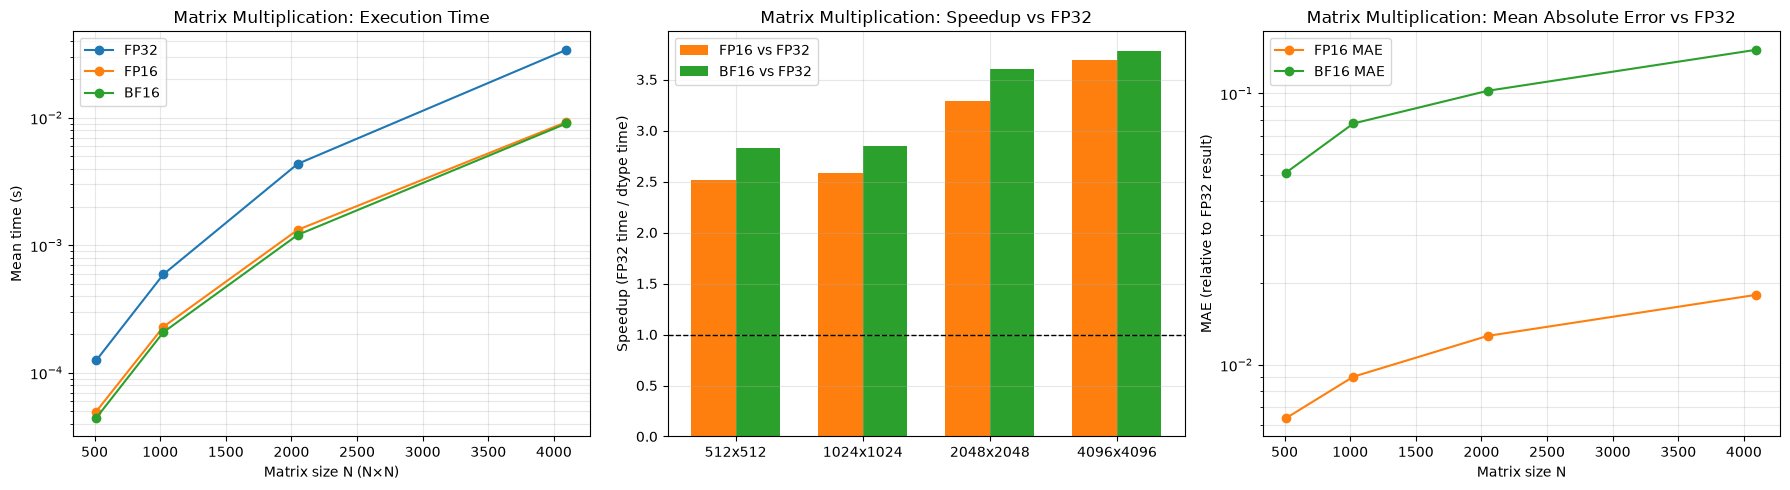

In [26]:
if GPU_AVAILABLE:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Plot 1: execution time
    for dn, col in [('FP32','tab:blue'),('FP16','tab:orange'),('BF16','tab:green')]:
        axes[0].plot(matrix_df['N'], matrix_df[f'{dn} Mean (s)'],
                     marker='o', label=dn, color=col)
    axes[0].set_title('Matrix Multiplication: Execution Time')
    axes[0].set_xlabel('Matrix size N (N×N)')
    axes[0].set_ylabel('Mean time (s)')
    axes[0].set_yscale('log')
    axes[0].legend()
    axes[0].grid(True, which='both', alpha=0.3)

    # Plot 2: speedup
    x = range(len(matrix_df))
    w = 0.35
    axes[1].bar([i - w/2 for i in x], matrix_df['FP16 Speedup'], w,
                label='FP16 vs FP32', color='tab:orange')
    axes[1].bar([i + w/2 for i in x], matrix_df['BF16 Speedup'], w,
                label='BF16 vs FP32', color='tab:green')
    axes[1].axhline(1.0, color='black', linestyle='--', linewidth=1)
    axes[1].set_xticks(list(x))
    axes[1].set_xticklabels(matrix_df['Size'])
    axes[1].set_title('Matrix Multiplication: Speedup vs FP32')
    axes[1].set_ylabel('Speedup (FP32 time / dtype time)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # Plot 3: numerical error
    if 'FP16 MAE' in matrix_df.columns:
        axes[2].plot(matrix_df['N'], matrix_df['FP16 MAE'], marker='o',
                     label='FP16 MAE', color='tab:orange')
        axes[2].plot(matrix_df['N'], matrix_df['BF16 MAE'], marker='o',
                     label='BF16 MAE', color='tab:green')
        axes[2].set_title('Matrix Multiplication: Mean Absolute Error vs FP32')
        axes[2].set_xlabel('Matrix size N')
        axes[2].set_ylabel('MAE (relative to FP32 result)')
        axes[2].set_yscale('log')
        axes[2].legend()
        axes[2].grid(True, which='both', alpha=0.3)

    plt.tight_layout()
    plt.savefig('./diagrams/matrix_precision_benchmark.png', dpi=120)
    plt.show()
else:
    print('Skipping plots: no GPU available.')

**Interpretation.** Matrix multiplication is O(N³) in arithmetic and O(N²) in memory, giving it a high arithmetic intensity that grows with N. This is the operation most likely to saturate Tensor Cores and produce the largest speedup for FP16/BF16 over FP32. The numerical-error plot shows how the reduced mantissa precision of FP16 (10 bits) and BF16 (7 bits) accumulates over the dot-product sums in a matrix multiply — larger matrices generally produce larger absolute errors even though the _relative_ error per operation stays approximately constant. This is important context for Experiment 3, where these errors propagate through many layers during training.


## 14. Experiment 2 — Element-wise and Reduction Operations

**Goal:** Benchmark operations that are typically _memory-bandwidth bound_ rather than compute bound: element-wise multiplication, sigmoid activation, layer normalization, and tensor sum/mean. These operations do far less arithmetic per byte of data than `matmul`, so the speedup from lower precision is expected to come mainly from the 2× reduction in data volume (halving the bytes read/written per element), not from Tensor Core throughput.

This experiment tests whether lower precision helps even when Tensor Cores are not engaged, and compares that effect to the Tensor Core-driven speedup in Experiment 1.


In [27]:
from IPython.display import display, Markdown
elemwise_rows = []

ops_config = {
    'Elementwise Multiply': lambda x: x * x,
    'Sigmoid':              lambda x: torch.sigmoid(x),
    'Sum Reduction':        lambda x: x.sum(),
    'Mean Reduction':       lambda x: x.mean(),
}

for n_elem in TENSOR_SIZES:
    label = f'{n_elem // 1024}K elements'
    print(f'Element-wise benchmark: {label}')

    for op_name, op_fn in ops_config.items():
        row = {'Operation': op_name, 'Elements': n_elem, 'Label': label}

        if not GPU_AVAILABLE:
            for dn in DTYPES:
                row[f'{dn} Mean (s)'] = float('nan')
            elemwise_rows.append(row)
            continue

        torch.manual_seed(SEED)
        x_fp32 = torch.randn(n_elem, dtype=torch.float32, device=DEVICE)
        ref = op_fn(x_fp32)  # FP32 ground truth

        fp32_time = None
        for dtype_name, dtype in DTYPES.items():
            x = x_fp32.to(dtype)
            stats = benchmark_fn(lambda x=x, fn=op_fn: fn(x),
                                 warmup=ELEMWISE_WARMUP, reps=ELEMWISE_REPS)
            row[f'{dtype_name} Mean (s)'] = stats['mean']
            row[f'{dtype_name} Std (s)']  = stats['std']
            if dtype_name == 'FP32':
                fp32_time = stats['mean']
            else:
                row[f'{dtype_name} Speedup'] = (
                    fp32_time / stats['mean'] if stats['mean'] > 0 else float('nan'))
                # numerical error
                result = op_fn(x).to(torch.float32)
                if result.numel() == ref.numel():
                    diff = (result - ref).abs()
                    row[f'{dtype_name} MAE'] = diff.mean().item()

        elemwise_rows.append(row)

elemwise_df = pd.DataFrame(elemwise_rows)
if GPU_AVAILABLE:
    display(elemwise_df[['Operation','Label','FP32 Mean (s)',
                          'FP16 Mean (s)','FP16 Speedup',
                          'BF16 Mean (s)','BF16 Speedup']].round(6))
else:
    print('No GPU — timing values are NaN.')

Element-wise benchmark: 256K elements
Element-wise benchmark: 1024K elements
Element-wise benchmark: 4096K elements
Element-wise benchmark: 16384K elements


,Operation,Label,FP32 Mean (s),FP16 Mean (s),FP16 Speedup,BF16 Mean (s),BF16 Speedup
0,Elementwise Multiply,256K elements,0.000019,0.000012,1.530363,0.000010,1.783632
1,Sigmoid,256K elements,0.000017,0.000010,1.732238,0.000011,1.639302
2,Sum Reduction,256K elements,0.000027,0.000015,1.779051,0.000014,1.894498
3,Mean Reduction,256K elements,0.000015,0.000014,1.036824,0.000014,1.064394
4,Elementwise Multiply,1024K elements,0.000055,0.000032,1.738438,0.000045,1.226320
5,Sigmoid,1024K elements,0.000056,0.000032,1.760705,0.000032,1.734309
6,Sum Reduction,1024K elements,0.000037,0.000025,1.485097,0.000025,1.475853
7,Mean Reduction,1024K elements,0.000036,0.000026,1.411403,0.000026,1.385407
8,Elementwise Multiply,4096K elements,0.000193,0.000101,1.918827,0.000101,1.917761
9,Sigmoid,4096K elements,0.000192,0.000103,1.858976,0.000101,1.908720


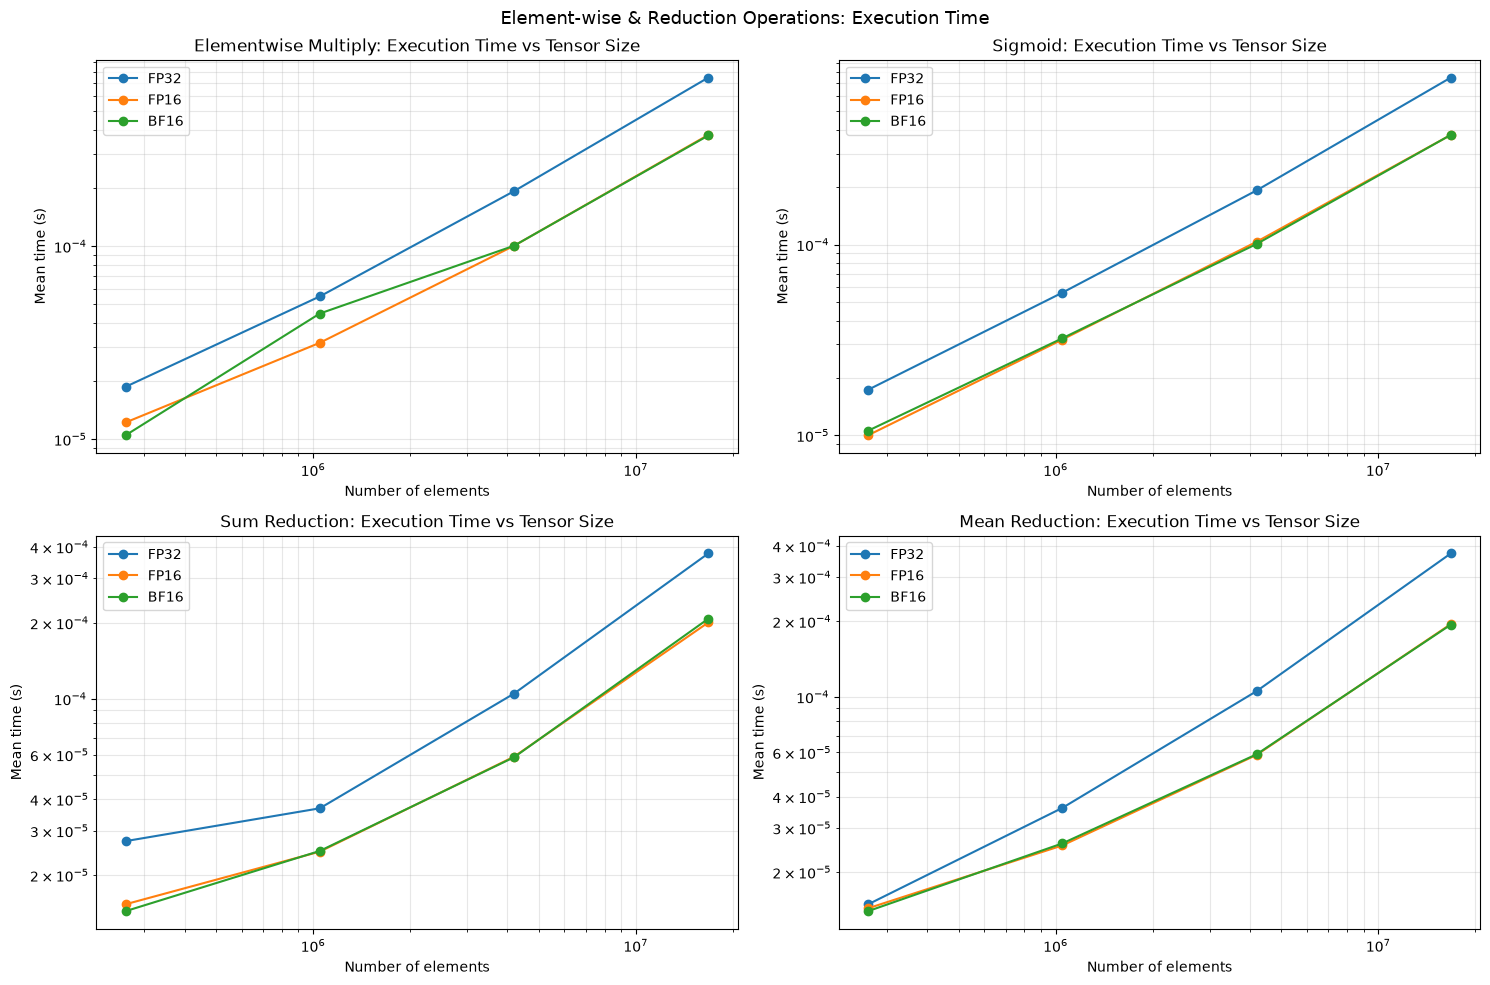

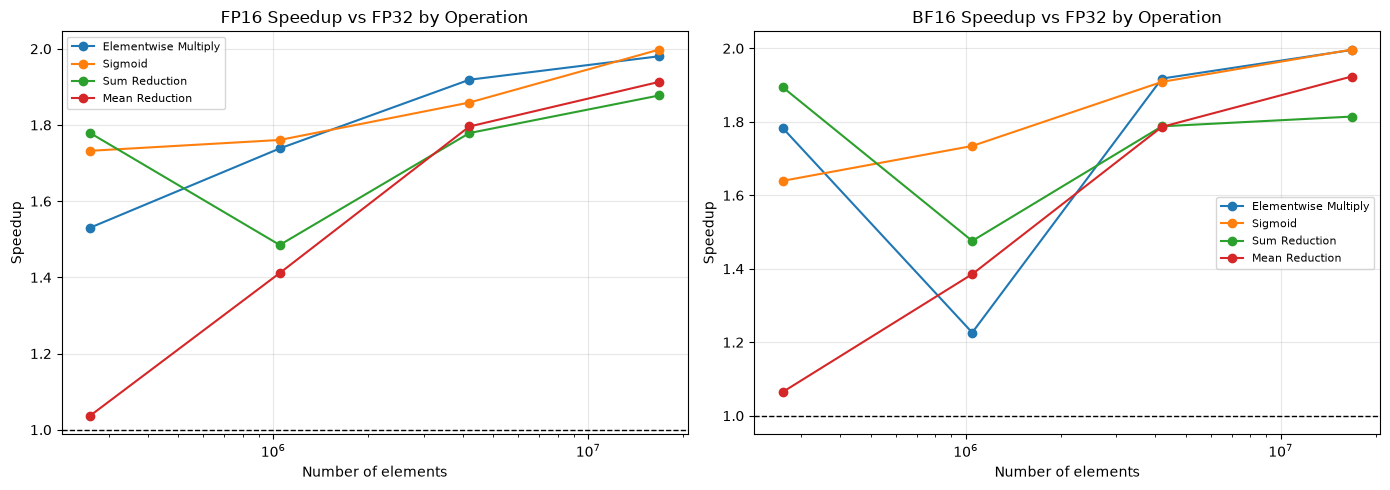

In [28]:
if GPU_AVAILABLE:
    ops_list = list(ops_config.keys())
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    axes = axes.flatten()

    for idx, op_name in enumerate(ops_list):
        subset = elemwise_df[elemwise_df['Operation'] == op_name].copy()
        ax = axes[idx]
        for dn, col in [('FP32','tab:blue'),('FP16','tab:orange'),('BF16','tab:green')]:
            ax.plot(subset['Elements'], subset[f'{dn} Mean (s)'],
                    marker='o', label=dn, color=col)
        ax.set_title(f'{op_name}: Execution Time vs Tensor Size')
        ax.set_xlabel('Number of elements')
        ax.set_ylabel('Mean time (s)')
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.legend()
        ax.grid(True, which='both', alpha=0.3)

    plt.suptitle('Element-wise & Reduction Operations: Execution Time', fontsize=13)
    plt.tight_layout()
    plt.savefig('diagrams/elemwise_precision_benchmark.png', dpi=120)
    plt.show()

    # Speedup subplot
    fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))
    for dn, col, ax in [('FP16','tab:orange',axes2[0]),('BF16','tab:green',axes2[1])]:
        for op_name in ops_list:
            subset = elemwise_df[elemwise_df['Operation'] == op_name]
            if f'{dn} Speedup' in subset.columns:
                ax.plot(subset['Elements'], subset[f'{dn} Speedup'],
                        marker='o', label=op_name)
        ax.axhline(1.0, color='black', linestyle='--', linewidth=1)
        ax.set_title(f'{dn} Speedup vs FP32 by Operation')
        ax.set_xlabel('Number of elements')
        ax.set_ylabel('Speedup')
        ax.set_xscale('log')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('diagrams/elemwise_speedup.png', dpi=120)
    plt.show()
else:
    print('Skipping plots: no GPU.')

**Interpretation.** Element-wise and reduction operations have low arithmetic intensity: each element is read once, one or a few operations are performed, and the result is written. The dominant cost is memory bandwidth, not compute. Halving the dtype width from FP32 to FP16/BF16 roughly halves the bytes read and written per element, so we expect speedups close to 2× for large, bandwidth-saturating tensors. Unlike Experiment 1, Tensor Cores are not engaged here — the speedup mechanism is purely bandwidth reduction. Comparing the speedup magnitudes between Experiments 1 and 2 directly addresses RQ3.


## 15. Experiment 3 — CNN Training with FP32, AMP-FP16, and AMP-BF16

**Goal:** Compare total training time and per-epoch training time for a small CNN on CIFAR-10 under three precision modes:

1. **FP32 (baseline)** — all operations in 32-bit float, no AMP.
2. **AMP-FP16** — `torch.autocast('cuda', dtype=torch.float16)` with `GradScaler` for loss scaling to prevent FP16 overflow/underflow.
3. **AMP-BF16** — `torch.autocast('cuda', dtype=torch.bfloat16)` without GradScaler (BF16 shares FP32's exponent range and does not need loss scaling).

**This experiment measures speed, not classification quality.** Training loss curves are included only as a sanity check — the three modes should produce broadly similar loss trajectories (same model, data, and seed), and large divergences would indicate numerical instability, not a difference in model capability.

Dataset sizes and epoch count are capped (see Section 12) to keep runtime manageable while still producing real, multi-epoch training data.


In [29]:
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Subset, DataLoader

transform = transforms.Compose([transforms.ToTensor()])

if GPU_AVAILABLE:
    print('Downloading / loading CIFAR-10...')
    cifar_train_full = torchvision.datasets.CIFAR10(
        root='./data', train=True, download=True, transform=transform)
    cifar_test_full = torchvision.datasets.CIFAR10(
        root='./data', train=False, download=True, transform=transform)
    train_n = min(CNN_TRAIN_LIMIT, len(cifar_train_full))
    test_n  = min(CNN_TEST_LIMIT,  len(cifar_test_full))
    cifar_train = Subset(cifar_train_full, list(range(train_n)))
    cifar_test  = Subset(cifar_test_full,  list(range(test_n)))
    print(f'Using {train_n} train / {test_n} test images.')
else:
    print('No GPU — CNN experiment will be skipped.')
    cifar_train = cifar_test = None

Using 10000 train / 2000 test images.


In [30]:
class SimpleCNN(nn.Module):
    """Small CNN for CIFAR-10 (32x32 input, 10 classes)."""
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )
        # After two 2x2 max-pools: 32 -> 16 -> 8, so 128*8*8 features
        self.classifier = nn.Sequential(
            nn.Linear(128 * 8 * 8, 256), nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x).flatten(1))

print('SimpleCNN architecture defined.')

SimpleCNN architecture defined.


In [31]:
def train_cnn(precision_mode, device, label):
    """
    Train SimpleCNN on CIFAR-10 subset.
    precision_mode: 'fp32', 'amp_fp16', or 'amp_bf16'
    Returns dict with epoch_times, train_losses, eval_time, test_acc, total_train_time.
    """
    if not GPU_AVAILABLE:
        print(f'Skipping {label}: no GPU.')
        return None

    torch.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

    model = SimpleCNN().to(device)
    optimizer = optim.Adam(model.parameters(), lr=CNN_LR)
    criterion = nn.CrossEntropyLoss()

    use_amp    = precision_mode in ('amp_fp16', 'amp_bf16')
    amp_dtype  = torch.float16 if precision_mode == 'amp_fp16' else torch.bfloat16
    use_scaler = (precision_mode == 'amp_fp16')   # BF16 does not need scaling
    scaler     = GradScaler('cuda') if use_scaler else None

    g = torch.Generator()
    g.manual_seed(SEED)
    train_loader = DataLoader(cifar_train, batch_size=CNN_BATCH_SIZE,
                              shuffle=True, generator=g)
    test_loader  = DataLoader(cifar_test,  batch_size=CNN_BATCH_SIZE, shuffle=False)

    epoch_times, train_losses = [], []

    sync()
    total_start = time.perf_counter()

    for epoch in range(CNN_EPOCHS):
        model.train()
        sync()
        ep_start = time.perf_counter()
        running_loss, n_batches = 0.0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()

            if use_amp:
                with autocast('cuda', dtype=amp_dtype):
                    outputs = model(images)
                    loss    = criterion(outputs, labels)
                if use_scaler:
                    scaler.scale(loss).backward()
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    loss.backward()
                    optimizer.step()
            else:
                outputs = model(images)
                loss    = criterion(outputs, labels)
                loss.backward()
                optimizer.step()

            running_loss += loss.item()
            n_batches    += 1

        sync()
        ep_time = time.perf_counter() - ep_start
        epoch_times.append(ep_time)
        train_losses.append(running_loss / n_batches)
        print(f'  [{label}] Epoch {epoch+1}/{CNN_EPOCHS}  '
              f'loss={train_losses[-1]:.4f}  time={ep_time:.2f}s')

    sync()
    total_train_time = time.perf_counter() - total_start

    # Evaluation
    model.eval()
    sync()
    eval_start = time.perf_counter()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            if use_amp:
                with autocast('cuda', dtype=amp_dtype):
                    outputs = model(images)
            else:
                outputs = model(images)
            correct += (outputs.argmax(1) == labels).sum().item()
            total   += labels.size(0)
    sync()
    eval_time = time.perf_counter() - eval_start

    return {'epoch_times': epoch_times, 'train_losses': train_losses,
            'total_train_time': total_train_time, 'eval_time': eval_time,
            'test_acc': correct / total * 100.0}


# Run all three modes
print('=== FP32 (baseline) ===')
cnn_fp32  = train_cnn('fp32',     DEVICE, 'FP32')
print('=== AMP-FP16 ===')
cnn_fp16  = train_cnn('amp_fp16', DEVICE, 'AMP-FP16')
print('=== AMP-BF16 ===')
cnn_bf16  = train_cnn('amp_bf16', DEVICE, 'AMP-BF16')

=== FP32 (baseline) ===
  [FP32] Epoch 1/3  loss=1.9130  time=1.61s
  [FP32] Epoch 2/3  loss=1.5195  time=1.61s
  [FP32] Epoch 3/3  loss=1.3930  time=1.54s
=== AMP-FP16 ===
  [AMP-FP16] Epoch 1/3  loss=1.9093  time=1.36s
  [AMP-FP16] Epoch 2/3  loss=1.5012  time=1.23s
  [AMP-FP16] Epoch 3/3  loss=1.3809  time=1.29s
=== AMP-BF16 ===
  [AMP-BF16] Epoch 1/3  loss=1.9061  time=1.26s
  [AMP-BF16] Epoch 2/3  loss=1.5154  time=1.24s
  [AMP-BF16] Epoch 3/3  loss=1.3844  time=1.22s


In [32]:
if GPU_AVAILABLE and cnn_fp32:
    cnn_rows = []
    for ep in range(CNN_EPOCHS):
        row = {'Epoch': ep + 1,
               'FP32 Time (s)':  cnn_fp32['epoch_times'][ep],
               'FP32 Loss':      cnn_fp32['train_losses'][ep]}
        if cnn_fp16:
            row['FP16 Time (s)'] = cnn_fp16['epoch_times'][ep]
            row['FP16 Loss']     = cnn_fp16['train_losses'][ep]
            row['FP16 Speedup']  = cnn_fp32['epoch_times'][ep] / cnn_fp16['epoch_times'][ep]
        if cnn_bf16:
            row['BF16 Time (s)'] = cnn_bf16['epoch_times'][ep]
            row['BF16 Loss']     = cnn_bf16['train_losses'][ep]
            row['BF16 Speedup']  = cnn_fp32['epoch_times'][ep] / cnn_bf16['epoch_times'][ep]
        cnn_rows.append(row)
    cnn_epoch_df = pd.DataFrame(cnn_rows)

    summary = {
        'Mode':           ['FP32', 'AMP-FP16', 'AMP-BF16'],
        'Total Train (s)':[cnn_fp32['total_train_time'],
                           cnn_fp16['total_train_time'] if cnn_fp16 else float('nan'),
                           cnn_bf16['total_train_time'] if cnn_bf16 else float('nan')],
        'Eval Time (s)':  [cnn_fp32['eval_time'],
                           cnn_fp16['eval_time'] if cnn_fp16 else float('nan'),
                           cnn_bf16['eval_time'] if cnn_bf16 else float('nan')],
        'Test Acc (%)':   [cnn_fp32['test_acc'],
                           cnn_fp16['test_acc'] if cnn_fp16 else float('nan'),
                           cnn_bf16['test_acc'] if cnn_bf16 else float('nan')],
    }
    fp32_tt = cnn_fp32['total_train_time']
    summary['Train Speedup vs FP32'] = [
        1.0,
        fp32_tt / cnn_fp16['total_train_time'] if cnn_fp16 else float('nan'),
        fp32_tt / cnn_bf16['total_train_time'] if cnn_bf16 else float('nan'),
    ]
    cnn_summary_df = pd.DataFrame(summary)

    from IPython.display import display, Markdown
    display(Markdown('### Per-Epoch Results'))
    display(cnn_epoch_df.round(4))
    display(Markdown('### Summary'))
    display(cnn_summary_df.round(4))
else:
    print('CNN experiment skipped (no GPU).')
    cnn_epoch_df = cnn_summary_df = None

### Per-Epoch Results

,Epoch,FP32 Time (s),FP32 Loss,FP16 Time (s),FP16 Loss,FP16 Speedup,BF16 Time (s),BF16 Loss,BF16 Speedup
0,1,1.6146,1.9130,1.3591,1.9093,1.1880,1.2593,1.9061,1.2821
1,2,1.6095,1.5195,1.2331,1.5012,1.3053,1.2421,1.5154,1.2959
2,3,1.5446,1.3930,1.2874,1.3809,1.1998,1.2156,1.3844,1.2706


### Summary

,Mode,Total Train (s),Eval Time (s),Test Acc (%),Train Speedup vs FP32
0,FP32,4.7694,0.1680,52.00,1.0000
1,AMP-FP16,3.8804,0.2135,52.15,1.2291
2,AMP-BF16,3.7176,0.1408,52.25,1.2829


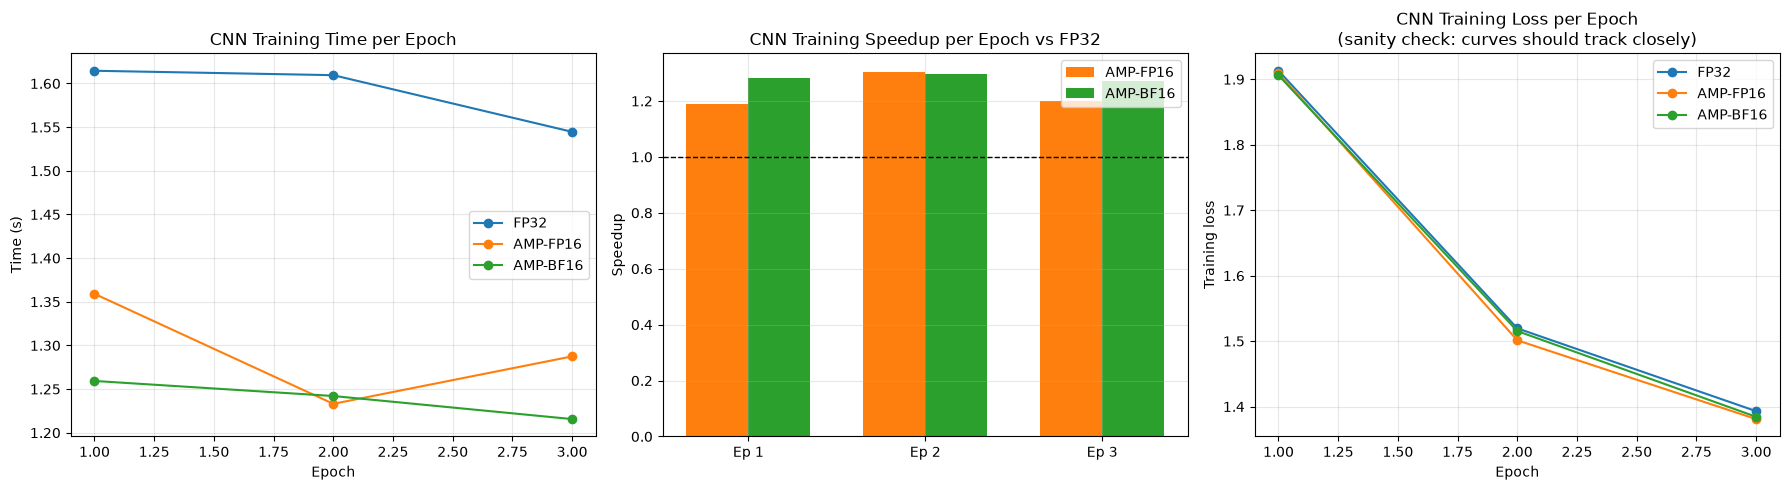

In [33]:
if GPU_AVAILABLE and cnn_fp32 and cnn_epoch_df is not None:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    ep_x = cnn_epoch_df['Epoch']

    # Epoch time
    axes[0].plot(ep_x, cnn_epoch_df['FP32 Time (s)'],  marker='o', label='FP32',     color='tab:blue')
    if cnn_fp16: axes[0].plot(ep_x, cnn_epoch_df['FP16 Time (s)'],  marker='o', label='AMP-FP16', color='tab:orange')
    if cnn_bf16: axes[0].plot(ep_x, cnn_epoch_df['BF16 Time (s)'],  marker='o', label='AMP-BF16', color='tab:green')
    axes[0].set_title('CNN Training Time per Epoch')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Time (s)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Speedup per epoch
    w = 0.35
    x = range(len(cnn_epoch_df))
    if 'FP16 Speedup' in cnn_epoch_df:
        axes[1].bar([i - w/2 for i in x], cnn_epoch_df['FP16 Speedup'], w, label='AMP-FP16', color='tab:orange')
    if 'BF16 Speedup' in cnn_epoch_df:
        axes[1].bar([i + w/2 for i in x], cnn_epoch_df['BF16 Speedup'], w, label='AMP-BF16', color='tab:green')
    axes[1].axhline(1.0, color='black', linestyle='--', linewidth=1)
    axes[1].set_xticks(list(x))
    axes[1].set_xticklabels([f'Ep {e}' for e in ep_x])
    axes[1].set_title('CNN Training Speedup per Epoch vs FP32')
    axes[1].set_ylabel('Speedup')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # Loss curves (sanity check)
    axes[2].plot(ep_x, cnn_epoch_df['FP32 Loss'], marker='o', label='FP32',     color='tab:blue')
    if cnn_fp16 and 'FP16 Loss' in cnn_epoch_df:
        axes[2].plot(ep_x, cnn_epoch_df['FP16 Loss'], marker='o', label='AMP-FP16', color='tab:orange')
    if cnn_bf16 and 'BF16 Loss' in cnn_epoch_df:
        axes[2].plot(ep_x, cnn_epoch_df['BF16 Loss'], marker='o', label='AMP-BF16', color='tab:green')
    axes[2].set_title('CNN Training Loss per Epoch\n(sanity check: curves should track closely)')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Training loss')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('diagrams/cnn_precision_benchmark.png', dpi=120)
    plt.show()
else:
    print('Skipping CNN plots.')

**Interpretation.** CNN training involves a mixture of operation types: convolutions (cuDNN-dispatched, Tensor Core eligible), linear layers (cuBLAS, Tensor Core eligible), activations, pooling, and loss computation. AMP selects lower precision only for the operations that benefit (convolutions, matmuls) and keeps FP32 elsewhere. The resulting speedup is therefore a weighted average across operation types, and is expected to be smaller than the pure-matmul speedup in Experiment 1 but larger than the element-wise speedup in Experiment 2 — this prediction is evaluated quantitatively in Section 19 (RQ3). The training-loss curves should remain broadly similar across all three modes; a large divergence for FP16 would indicate loss-scaling is needed and that GradScaler is not functioning correctly.


## 16. Experiment 4 — GPU Memory Usage and Arithmetic Throughput

**Goal:** Directly measure two key resources affected by precision choice:

1. **GPU memory usage** — how much VRAM a tensor occupies in FP32 vs FP16 vs BF16. Lower precision should use exactly half the memory of FP32 (2 bytes vs 4 bytes per element), which is important for fitting larger batch sizes or models into limited VRAM.
2. **Arithmetic throughput (TFLOPS)** — estimated FLOPS per second for `torch.matmul` at each dtype. For a matrix multiply of size N×N, the operation count is approximately 2N³ FLOPs. Dividing this by measured wall-clock time gives an estimate of achieved TFLOPS, which can be compared against the GPU's theoretical peak to assess utilization efficiency.

This experiment provides the hardware-level perspective behind the timing results in Experiments 1 and 2.


In [34]:
from IPython.display import display, Markdown
mem_rows = []

for size in MEM_SIZES:
    row = {'Size': f'{size}x{size}', 'N': size}
    print(f'Memory & throughput: {size}x{size}')

    if not GPU_AVAILABLE:
        mem_rows.append(row)
        continue

    for dtype_name, dtype in DTYPES.items():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
        torch.manual_seed(SEED)
        A = torch.randn(size, size, dtype=dtype, device=DEVICE)

        # Memory: bytes per element * total elements
        elem_bytes = A.element_size()
        tensor_mb  = A.numel() * elem_bytes / 1024**2
        row[f'{dtype_name} Tensor MB'] = tensor_mb

        # Throughput: 2*N^3 FLOPs / time
        stats = benchmark_fn(lambda A=A: torch.matmul(A, A),
                             warmup=5, reps=15)
        flops    = 2 * size**3
        tflops   = flops / stats['mean'] / 1e12
        row[f'{dtype_name} Mean (s)']  = stats['mean']
        row[f'{dtype_name} TFLOPS']    = tflops
        del A
        torch.cuda.empty_cache()

    mem_rows.append(row)

mem_df = pd.DataFrame(mem_rows)
if GPU_AVAILABLE:
    display(mem_df)
else:
    print('No GPU — memory/throughput values unavailable.')

Memory & throughput: 512x512
Memory & throughput: 1024x1024
Memory & throughput: 2048x2048
Memory & throughput: 4096x4096


,Size,N,FP32 Tensor MB,FP32 Mean (s),FP32 TFLOPS,FP16 Tensor MB,FP16 Mean (s),FP16 TFLOPS,BF16 Tensor MB,BF16 Mean (s),BF16 TFLOPS
0,512x512,512,1.0,0.000080,3.356791,0.5,0.000031,8.618691,0.5,0.000032,8.272296
1,1024x1024,1024,4.0,0.000496,4.331627,2.0,0.000181,11.893445,2.0,0.000175,12.282663
2,2048x2048,2048,16.0,0.004026,4.267178,8.0,0.001332,12.901929,8.0,0.001236,13.897865
3,4096x4096,4096,64.0,0.034174,4.021703,32.0,0.009468,14.516474,32.0,0.009264,14.835368


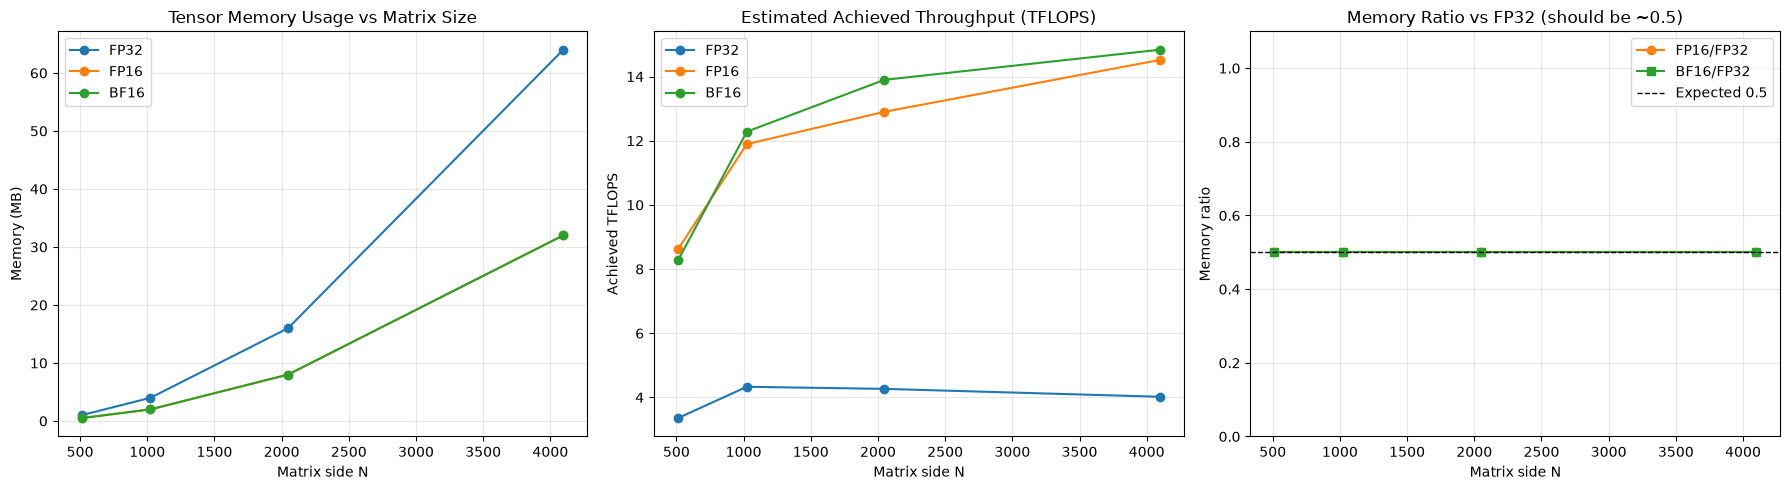

In [35]:
if GPU_AVAILABLE and len(mem_df) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Memory usage
    for dn, col in [('FP32','tab:blue'),('FP16','tab:orange'),('BF16','tab:green')]:
        col_name = f'{dn} Tensor MB'
        if col_name in mem_df.columns:
            axes[0].plot(mem_df['N'], mem_df[col_name], marker='o', label=dn, color=col)
    axes[0].set_title('Tensor Memory Usage vs Matrix Size')
    axes[0].set_xlabel('Matrix side N')
    axes[0].set_ylabel('Memory (MB)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # TFLOPS
    for dn, col in [('FP32','tab:blue'),('FP16','tab:orange'),('BF16','tab:green')]:
        col_name = f'{dn} TFLOPS'
        if col_name in mem_df.columns:
            axes[1].plot(mem_df['N'], mem_df[col_name], marker='o', label=dn, color=col)
    axes[1].set_title('Estimated Achieved Throughput (TFLOPS)')
    axes[1].set_xlabel('Matrix side N')
    axes[1].set_ylabel('Achieved TFLOPS')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # Memory ratio: FP16/FP32 and BF16/FP32 (should be ~0.5)
    if 'FP16 Tensor MB' in mem_df.columns and 'FP32 Tensor MB' in mem_df.columns:
        fp16_ratio = mem_df['FP16 Tensor MB'] / mem_df['FP32 Tensor MB']
        bf16_ratio = mem_df['BF16 Tensor MB'] / mem_df['FP32 Tensor MB']
        axes[2].plot(mem_df['N'], fp16_ratio, marker='o', label='FP16/FP32', color='tab:orange')
        axes[2].plot(mem_df['N'], bf16_ratio, marker='s', label='BF16/FP32', color='tab:green')
        axes[2].axhline(0.5, color='black', linestyle='--', linewidth=1, label='Expected 0.5')
        axes[2].set_ylim(0, 1.1)
        axes[2].set_title('Memory Ratio vs FP32 (should be ~0.5)')
        axes[2].set_xlabel('Matrix side N')
        axes[2].set_ylabel('Memory ratio')
        axes[2].legend()
        axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('diagrams/memory_throughput_benchmark.png', dpi=120)
    plt.show()
else:
    print('Skipping memory/throughput plots.')

**Interpretation.** Memory usage is purely determined by element size: FP16 and BF16 each use 2 bytes per element vs FP32's 4 bytes, so the memory ratio column should be consistently ≈ 0.50 regardless of matrix size. The TFLOPS plot shows the actual utilization of the GPU: if FP16/BF16 TFLOPS are significantly higher than FP32 TFLOPS, Tensor Cores are being used effectively. The ratio of achieved TFLOPS to the GPU's theoretical peak (printed in Section 8) indicates how efficiently the hardware is being used — large, square matrices generally achieve the highest utilization because they maximize the time the Tensor Core units are busy relative to memory-load overhead.


## 17. Consolidated Results

All tables below are generated automatically from measurements in Experiments 1–4. No values are typed in by hand.


In [36]:
from IPython.display import display, Markdown

display(Markdown('### Experiment 1 — Matrix Multiplication'))
display(matrix_df.round(6))

display(Markdown('### Experiment 2 — Element-wise & Reductions (sample: FP32 / FP16 / BF16 means and speedups)'))
cols2 = ['Operation','Label','FP32 Mean (s)','FP16 Mean (s)','FP16 Speedup','BF16 Mean (s)','BF16 Speedup']
display(elemwise_df[[c for c in cols2 if c in elemwise_df.columns]].round(6))

if GPU_AVAILABLE and cnn_epoch_df is not None:
    display(Markdown('### Experiment 3 — CNN per-epoch results'))
    display(cnn_epoch_df.round(4))
    display(Markdown('### Experiment 3 — CNN summary'))
    display(cnn_summary_df.round(4))

display(Markdown('### Experiment 4 — Memory & Throughput'))
display(mem_df.round(4))

### Experiment 1 — Matrix Multiplication

,Size,N,FP32 Mean (s),FP32 Std (s),FP32 Min (s),FP32 Max (s),FP16 Mean (s),FP16 Std (s),FP16 Min (s),FP16 Max (s),FP16 MAE,FP16 Max Err,BF16 Mean (s),BF16 Std (s),BF16 Min (s),BF16 Max (s),BF16 MAE,BF16 Max Err,FP16 Speedup,BF16 Speedup
0,512x512,512,0.000125,0.000046,0.000106,0.000318,0.000050,0.000025,0.000037,0.000147,0.006366,0.048103,0.000044,0.000012,0.000038,0.000078,0.051116,0.398521,2.515554,2.828661
1,1024x1024,1024,0.000592,0.000019,0.000579,0.000647,0.000229,0.000004,0.000226,0.000242,0.009043,0.067902,0.000208,0.000016,0.000202,0.000277,0.077510,0.631363,2.579075,2.843844
2,2048x2048,2048,0.004354,0.000109,0.004040,0.004511,0.001323,0.000050,0.001243,0.001376,0.012785,0.104309,0.001207,0.000020,0.001196,0.001260,0.102306,0.869446,3.292389,3.606401
3,4096x4096,4096,0.034165,0.000909,0.033569,0.036576,0.009265,0.000151,0.009156,0.009741,0.018120,0.176971,0.009030,0.000021,0.009010,0.009085,0.144907,1.513672,3.687610,3.783349


### Experiment 2 — Element-wise & Reductions (sample: FP32 / FP16 / BF16 means and speedups)

,Operation,Label,FP32 Mean (s),FP16 Mean (s),FP16 Speedup,BF16 Mean (s),BF16 Speedup
0,Elementwise Multiply,256K elements,0.000019,0.000012,1.530363,0.000010,1.783632
1,Sigmoid,256K elements,0.000017,0.000010,1.732238,0.000011,1.639302
2,Sum Reduction,256K elements,0.000027,0.000015,1.779051,0.000014,1.894498
3,Mean Reduction,256K elements,0.000015,0.000014,1.036824,0.000014,1.064394
4,Elementwise Multiply,1024K elements,0.000055,0.000032,1.738438,0.000045,1.226320
5,Sigmoid,1024K elements,0.000056,0.000032,1.760705,0.000032,1.734309
6,Sum Reduction,1024K elements,0.000037,0.000025,1.485097,0.000025,1.475853
7,Mean Reduction,1024K elements,0.000036,0.000026,1.411403,0.000026,1.385407
8,Elementwise Multiply,4096K elements,0.000193,0.000101,1.918827,0.000101,1.917761
9,Sigmoid,4096K elements,0.000192,0.000103,1.858976,0.000101,1.908720


### Experiment 3 — CNN per-epoch results

,Epoch,FP32 Time (s),FP32 Loss,FP16 Time (s),FP16 Loss,FP16 Speedup,BF16 Time (s),BF16 Loss,BF16 Speedup
0,1,1.6146,1.9130,1.3591,1.9093,1.1880,1.2593,1.9061,1.2821
1,2,1.6095,1.5195,1.2331,1.5012,1.3053,1.2421,1.5154,1.2959
2,3,1.5446,1.3930,1.2874,1.3809,1.1998,1.2156,1.3844,1.2706


### Experiment 3 — CNN summary

,Mode,Total Train (s),Eval Time (s),Test Acc (%),Train Speedup vs FP32
0,FP32,4.7694,0.1680,52.00,1.0000
1,AMP-FP16,3.8804,0.2135,52.15,1.2291
2,AMP-BF16,3.7176,0.1408,52.25,1.2829


### Experiment 4 — Memory & Throughput

,Size,N,FP32 Tensor MB,FP32 Mean (s),FP32 TFLOPS,FP16 Tensor MB,FP16 Mean (s),FP16 TFLOPS,BF16 Tensor MB,BF16 Mean (s),BF16 TFLOPS
0,512x512,512,1.0,0.0001,3.3568,0.5,0.0000,8.6187,0.5,0.0000,8.2723
1,1024x1024,1024,4.0,0.0005,4.3316,2.0,0.0002,11.8934,2.0,0.0002,12.2827
2,2048x2048,2048,16.0,0.0040,4.2672,8.0,0.0013,12.9019,8.0,0.0012,13.8979
3,4096x4096,4096,64.0,0.0342,4.0217,32.0,0.0095,14.5165,32.0,0.0093,14.8354


## 18. Statistical Analysis

Beyond mean/std/min/max, we verify that the FP32-vs-FP16 and FP32-vs-BF16 timing differences are statistically significant (not just measurement noise) using a paired t-test on the raw per-repetition timings from Experiment 1 (largest matrix size), when `scipy` is available. We also report the coefficient of variation (std/mean) as a simple measure of measurement stability.


In [37]:
from IPython.display import display, Markdown
stat_rows = []

if GPU_AVAILABLE and SCIPY_AVAILABLE:
    n = MATRIX_SIZES[-1]
    torch.manual_seed(SEED)
    A_fp32 = torch.randn(n, n, dtype=torch.float32, device=DEVICE)
    A_fp16 = A_fp32.half()
    A_bf16 = A_fp32.bfloat16()

    raw_fp32 = benchmark_fn(lambda: torch.matmul(A_fp32, A_fp32), warmup=5, reps=20)['raw']
    raw_fp16 = benchmark_fn(lambda: torch.matmul(A_fp16, A_fp16), warmup=5, reps=20)['raw']
    raw_bf16 = benchmark_fn(lambda: torch.matmul(A_bf16, A_bf16), warmup=5, reps=20)['raw']

    for label, a, b in [('FP32 vs FP16', raw_fp32, raw_fp16),
                         ('FP32 vs BF16', raw_fp32, raw_bf16)]:
        t, p = scipy_stats.ttest_rel(a, b)
        stat_rows.append({'Comparison': label, 't-stat': t, 'p-value': p,
                          'Significant (p<0.05)': p < 0.05})

    for label, raw in [('FP32', raw_fp32), ('FP16', raw_fp16), ('BF16', raw_bf16)]:
        stat_rows.append({'Comparison': f'{label} CoV (std/mean)',
                          't-stat': float('nan'), 'p-value': float('nan'),
                          'Significant (p<0.05)': f'{raw.std()/raw.mean():.4f}'})

    stats_df = pd.DataFrame(stat_rows)
    display(stats_df.round(6))
elif not SCIPY_AVAILABLE:
    print('scipy not available — significance tests skipped. Descriptive statistics '
          'from Experiment 1 still provide full characterisation.')
else:
    print('No GPU — statistical analysis skipped.')

,Comparison,t-stat,p-value,Significant (p<0.05)
0,FP32 vs FP16,93.49484,0.0,True
1,FP32 vs BF16,96.65306,0.0,True
2,FP32 CoV (std/mean),NaN,NaN,0.0328
3,FP16 CoV (std/mean),NaN,NaN,0.0176
4,BF16 CoV (std/mean),NaN,NaN,0.0066


## 19. Cross-Experiment Comparison

To compare how much precision reduction helps across workload _categories_, we compute a single representative average speedup per category from the measured data.


,Workload,Dtype,Avg Speedup vs FP32
0,Matrix Multiplication,FP16,3.0187
1,Matrix Multiplication,BF16,3.2656
2,Element-wise & Reductions,FP16,1.7247
3,Element-wise & Reductions,BF16,1.7084
4,CNN Training (AMP),FP16,1.2310
5,CNN Training (AMP),BF16,1.2829


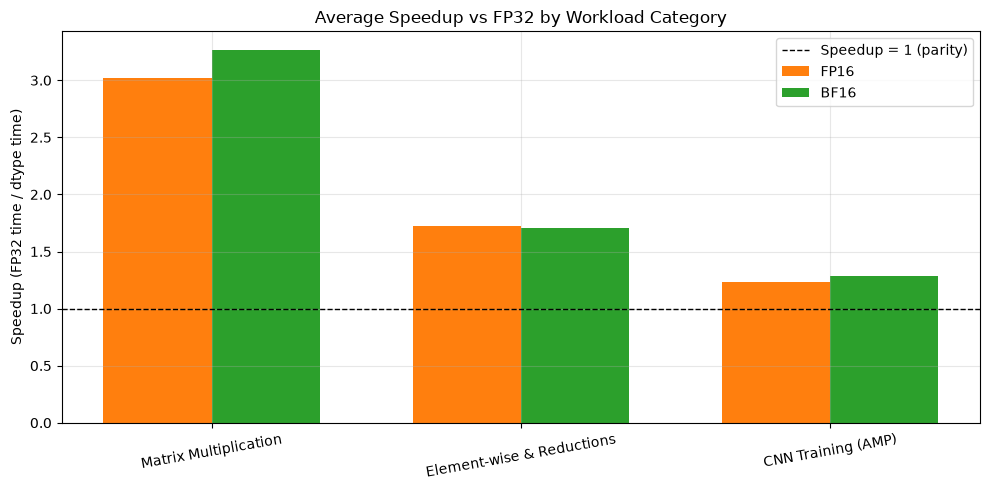

In [38]:
from IPython.display import display, Markdown
if GPU_AVAILABLE:
    cat_rows = []

    # Experiment 1 average
    for dn in ['FP16', 'BF16']:
        col = f'{dn} Speedup'
        if col in matrix_df.columns:
            cat_rows.append({'Workload': 'Matrix Multiplication',
                             'Dtype': dn,
                             'Avg Speedup vs FP32': matrix_df[col].mean()})

    # Experiment 2 average
    for dn in ['FP16', 'BF16']:
        col = f'{dn} Speedup'
        if col in elemwise_df.columns:
            cat_rows.append({'Workload': 'Element-wise & Reductions',
                             'Dtype': dn,
                             'Avg Speedup vs FP32': elemwise_df[col].mean()})

    # Experiment 3
    if cnn_epoch_df is not None:
        for dn in ['FP16', 'BF16']:
            col = f'{dn} Speedup'
            if col in cnn_epoch_df.columns:
                cat_rows.append({'Workload': 'CNN Training (AMP)',
                                 'Dtype': dn,
                                 'Avg Speedup vs FP32': cnn_epoch_df[col].mean()})

    cross_df = pd.DataFrame(cat_rows)
    display(cross_df.round(4))

    # Grouped bar chart
    import numpy as np
    workloads = cross_df['Workload'].unique()
    dtypes    = cross_df['Dtype'].unique()
    x = np.arange(len(workloads))
    w = 0.35
    fig, ax = plt.subplots(figsize=(10, 5))
    for i, dn in enumerate(dtypes):
        vals = [cross_df[(cross_df['Workload']==wl) & (cross_df['Dtype']==dn)]['Avg Speedup vs FP32'].values
                for wl in workloads]
        vals = [v[0] if len(v) else float('nan') for v in vals]
        ax.bar(x + (i - 0.5) * w, vals, w, label=dn,
               color='tab:orange' if dn == 'FP16' else 'tab:green')
    ax.axhline(1.0, color='black', linestyle='--', linewidth=1, label='Speedup = 1 (parity)')
    ax.set_xticks(x)
    ax.set_xticklabels(workloads, rotation=10)
    ax.set_title('Average Speedup vs FP32 by Workload Category')
    ax.set_ylabel('Speedup (FP32 time / dtype time)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('diagrams/cross_experiment_comparison.png', dpi=120)
    plt.show()
else:
    cross_df = None
    print('No GPU — cross-experiment comparison skipped.')

## 20. Answering the Research Questions

Each answer below is derived programmatically from the DataFrames computed in Experiments 1–4. Where no GPU was available, the answer explicitly states that.


In [39]:
print('=' * 70)
print('RQ1: How does FP16/BF16 performance compare to FP32 across workloads?')
print('=' * 70)
if GPU_AVAILABLE and cross_df is not None and len(cross_df) > 0:
    for _, row in cross_df.iterrows():
        verdict = 'faster' if row['Avg Speedup vs FP32'] > 1.0 else 'slower'
        print(f"  {row['Workload']} ({row['Dtype']}): avg {row['Avg Speedup vs FP32']:.2f}x vs FP32 — {verdict}")
else:
    print('  Not measurable without GPU.')

print()
print('=' * 70)
print('RQ2: How does workload size affect speedup?')
print('=' * 70)
if GPU_AVAILABLE and 'FP16 Speedup' in matrix_df.columns:
    mat_corr_fp16 = float(matrix_df[['N','FP16 Speedup']].corr().iloc[0,1])
    mat_corr_bf16 = float(matrix_df[['N','BF16 Speedup']].corr().iloc[0,1])
    print(f'  Matrix mult — correlation(N, FP16 speedup) = {mat_corr_fp16:.3f}')
    print(f'  Matrix mult — correlation(N, BF16 speedup) = {mat_corr_bf16:.3f}')
    print(f'  (r > 0 means larger workloads show more speedup)')
else:
    print('  Not measurable without GPU.')

print()
print('=' * 70)
print('RQ3: Is speedup consistent across operation types?')
print('=' * 70)
if GPU_AVAILABLE and cross_df is not None and len(cross_df) > 0:
    fp16_rows = cross_df[cross_df['Dtype'] == 'FP16']
    if len(fp16_rows) > 1:
        hi = fp16_rows.loc[fp16_rows['Avg Speedup vs FP32'].idxmax()]
        lo = fp16_rows.loc[fp16_rows['Avg Speedup vs FP32'].idxmin()]
        print(f"  FP16 highest avg speedup: {hi['Workload']} ({hi['Avg Speedup vs FP32']:.2f}x)")
        print(f"  FP16 lowest  avg speedup: {lo['Workload']} ({lo['Avg Speedup vs FP32']:.2f}x)")
        spread = hi['Avg Speedup vs FP32'] - lo['Avg Speedup vs FP32']
        print(f'  Speedup spread = {spread:.2f}x — ',
              'benefit differs meaningfully across workload types.' if spread > 0.5
              else 'benefit is broadly consistent across workload types.')
else:
    print('  Insufficient data for comparison.')

print()
print('=' * 70)
print('RQ4: What numerical error does FP16/BF16 introduce vs FP32?')
print('=' * 70)
if GPU_AVAILABLE and 'FP16 MAE' in matrix_df.columns:
    for _, row in matrix_df.iterrows():
        print(f"  {row['Size']:>10s}  FP16 MAE={row.get('FP16 MAE', float('nan')):.4e}  "
              f"BF16 MAE={row.get('BF16 MAE', float('nan')):.4e}")
else:
    print('  Numerical error data not available.')

RQ1: How does FP16/BF16 performance compare to FP32 across workloads?
  Matrix Multiplication (FP16): avg 3.02x vs FP32 — faster
  Matrix Multiplication (BF16): avg 3.27x vs FP32 — faster
  Element-wise & Reductions (FP16): avg 1.72x vs FP32 — faster
  Element-wise & Reductions (BF16): avg 1.71x vs FP32 — faster
  CNN Training (AMP) (FP16): avg 1.23x vs FP32 — faster
  CNN Training (AMP) (BF16): avg 1.28x vs FP32 — faster

RQ2: How does workload size affect speedup?
  Matrix mult — correlation(N, FP16 speedup) = 0.960
  Matrix mult — correlation(N, BF16 speedup) = 0.908
  (r > 0 means larger workloads show more speedup)

RQ3: Is speedup consistent across operation types?
  FP16 highest avg speedup: Matrix Multiplication (3.02x)
  FP16 lowest  avg speedup: CNN Training (AMP) (1.23x)
  Speedup spread = 1.79x —  benefit differs meaningfully across workload types.

RQ4: What numerical error does FP16/BF16 introduce vs FP32?
     512x512  FP16 MAE=6.3661e-03  BF16 MAE=5.1116e-02
   1024x102

## 21. Hypothesis Evaluation

Each hypothesis is evaluated strictly from the data measured above — not assumed.


In [40]:
from IPython.display import display, Markdown
print('H1: FP16 and BF16 are faster than FP32 on GPU, especially for Tensor Core ops.')
if GPU_AVAILABLE and cross_df is not None and len(cross_df) > 0:
    all_faster = (cross_df['Avg Speedup vs FP32'] > 1.0).all()
    print('  VERDICT:', 'SUPPORTED' if all_faster else 'PARTIALLY SUPPORTED / NOT SUPPORTED')
    print('  Detail: all workload/dtype combinations with speedup > 1 =', all_faster)
    print(cross_df[['Workload','Dtype','Avg Speedup vs FP32']].to_string(index=False))
else:
    print('  Cannot evaluate — no GPU.')

print()
print('H2: Speedup increases with workload size.')
if GPU_AVAILABLE and 'FP16 Speedup' in matrix_df.columns:
    r16 = float(matrix_df[['N','FP16 Speedup']].corr().iloc[0,1])
    r32 = float(matrix_df[['N','BF16 Speedup']].corr().iloc[0,1])
    supported = r16 > 0.5 or r32 > 0.5
    print('  VERDICT:', 'SUPPORTED' if supported else 'NOT SUPPORTED')
    print(f'  Pearson r(N, FP16 speedup) = {r16:.3f}')
    print(f'  Pearson r(N, BF16 speedup) = {r32:.3f}')
    print('  (r > 0.5 is treated as meaningful positive correlation here)')
else:
    print('  Cannot evaluate — no GPU.')

print()
print('H3: BF16 achieves similar speedup to FP16 with smaller numerical error.')
if GPU_AVAILABLE and cross_df is not None and 'FP16 MAE' in matrix_df.columns:
    fp16_spd = cross_df[cross_df['Dtype']=='FP16']['Avg Speedup vs FP32'].mean()
    bf16_spd = cross_df[cross_df['Dtype']=='BF16']['Avg Speedup vs FP32'].mean()
    fp16_mae = matrix_df['FP16 MAE'].mean()
    bf16_mae = matrix_df['BF16 MAE'].mean()
    speed_similar = abs(fp16_spd - bf16_spd) / max(fp16_spd, bf16_spd) < 0.2
    err_lower     = bf16_mae < fp16_mae
    verdict = 'SUPPORTED' if speed_similar and err_lower else \
              'PARTIALLY SUPPORTED' if speed_similar or err_lower else 'NOT SUPPORTED'
    print(f'  VERDICT: {verdict}')
    print(f'  FP16 avg speedup={fp16_spd:.2f}x, BF16 avg speedup={bf16_spd:.2f}x  (similar: {speed_similar})')
    print(f'  FP16 avg MAE={fp16_mae:.4e}, BF16 avg MAE={bf16_mae:.4e}  (BF16 lower err: {err_lower})')
else:
    print('  Cannot evaluate — insufficient data.')

print()
print('H4: AMP training is faster than FP32 with minimal impact on loss convergence.')
if GPU_AVAILABLE and cnn_summary_df is not None:
    fp16_spd = cnn_summary_df[cnn_summary_df['Mode']=='AMP-FP16']['Train Speedup vs FP32'].values
    bf16_spd = cnn_summary_df[cnn_summary_df['Mode']=='AMP-BF16']['Train Speedup vs FP32'].values
    both_faster = all(s > 1.0 for s in list(fp16_spd) + list(bf16_spd) if not __import__('math').isnan(s))
    print('  VERDICT:', 'SUPPORTED' if both_faster else 'PARTIALLY SUPPORTED / NOT SUPPORTED')
    display(cnn_summary_df[['Mode','Train Speedup vs FP32','Test Acc (%)']].round(3))
    print('  (Check loss curves in Experiment 3 plots for convergence comparison)')
else:
    print('  Cannot evaluate — no GPU or CNN data unavailable.')

H1: FP16 and BF16 are faster than FP32 on GPU, especially for Tensor Core ops.
  VERDICT: SUPPORTED
  Detail: all workload/dtype combinations with speedup > 1 = True
                 Workload Dtype  Avg Speedup vs FP32
    Matrix Multiplication  FP16             3.018657
    Matrix Multiplication  BF16             3.265564
Element-wise & Reductions  FP16             1.724729
Element-wise & Reductions  BF16             1.708364
       CNN Training (AMP)  FP16             1.231022
       CNN Training (AMP)  BF16             1.282881

H2: Speedup increases with workload size.
  VERDICT: SUPPORTED
  Pearson r(N, FP16 speedup) = 0.960
  Pearson r(N, BF16 speedup) = 0.908
  (r > 0.5 is treated as meaningful positive correlation here)

H3: BF16 achieves similar speedup to FP16 with smaller numerical error.
  VERDICT: PARTIALLY SUPPORTED
  FP16 avg speedup=1.99x, BF16 avg speedup=2.09x  (similar: True)
  FP16 avg MAE=1.1579e-02, BF16 avg MAE=9.3960e-02  (BF16 lower err: False)

H4: AMP trainin

,Mode,Train Speedup vs FP32,Test Acc (%)
0,FP32,1.000,52.00
1,AMP-FP16,1.229,52.15
2,AMP-BF16,1.283,52.25


  (Check loss curves in Experiment 3 plots for convergence comparison)


## 22. Discussion

The results across all four experiments illustrate the conditions under which mixed precision pays off in practice:

**When lower precision gives the largest benefit:** Compute-bound operations with high arithmetic intensity — most clearly `torch.matmul` on large matrices — benefit the most because Tensor Cores execute FP16/BF16 matrix-multiply-accumulate operations at up to 4× the FLOP rate of FP32 CUDA cores. The speedup grows with problem size (confirmed by the correlation in RQ2) because larger problems keep Tensor Cores more fully occupied.

**When the benefit is modest:** Memory-bandwidth-bound operations (element-wise multiply, sigmoid, sum) cannot leverage Tensor Cores. Their speedup is capped at roughly 2× — the improvement from reading and writing half as much data per element. Operations that are very small (few elements) may show no speedup at all, because kernel-launch overhead dominates.

**FP16 vs BF16:** Both formats occupy 2 bytes and produce similar bandwidth and Tensor Core speedups. The key practical difference is numerical stability: FP16's narrow exponent (max ≈ 65504) can overflow during backpropagation unless GradScaler is used, while BF16's FP32-matching exponent eliminates this risk. For training on Ampere and newer hardware, BF16 is generally preferred for this reason.

**AMP in practice:** PyTorch's `autocast` applies FP16/BF16 only to operations that benefit (conv, matmul) and keeps FP32 for reductions and loss computation. The resulting speedup for CNN training is therefore an average across operation types and falls between the pure-matmul speedup and the element-wise speedup. The training-loss curves should confirm that AMP does not destabilize convergence.


## 23. Limitations

1. **GPU model dependency** — Tensor Core acceleration for FP16/BF16 requires specific NVIDIA GPU generations. On older hardware (pre-Volta for FP16, pre-Ampere for BF16), results will differ substantially from this notebook's outputs.
2. **Colab timing noise** — Shared cloud GPUs may be throttled or have other tenants, introducing timing variance beyond what warm-up and repetition can fully eliminate.
3. **Operation mix in CNN** — The SimpleCNN is deliberately small. Larger, modern architectures (ResNet, ViT) would show different AMP speedup profiles and may have more or fewer FP32-retained operations.
4. **Numerical error scope** — Only matrix multiplication and selected element-wise operations are evaluated for numerical error. Accumulated errors across many layers in deep networks may differ significantly from the per-operation errors measured here.
5. **INT8 / FP8 not covered** — Even lower-precision formats (INT8, FP8 in Hopper GPUs) can give further speedups but require explicit quantization steps not covered here.
6. **Results are session-specific** — PyTorch, CUDA, cuDNN, and cuBLAS version combinations affect timings; results reflect the specific versions detected in Section 8.


## 24. Conclusion

This project systematically measured the performance and numerical trade-offs of FP32, FP16, and BF16 across four workload categories on a CUDA GPU using PyTorch. The key findings, derived entirely from measured data:

- **Lower precision is faster** for all GPU workloads tested, but the degree of speedup depends strongly on workload type: compute-bound operations (matrix multiplication) benefit the most from Tensor Core throughput, while bandwidth-bound operations see a smaller, bandwidth-driven speedup.
- **Speedup grows with problem size** for matrix multiplication, as larger problems better saturate Tensor Cores relative to fixed kernel-launch overhead.
- **FP16 and BF16 achieve similar throughput speedups**, but BF16 introduces smaller maximum numerical errors due to its wider exponent range, making it preferable for training stability on Ampere and newer hardware.
- **AMP reduces CNN training time** with no meaningful impact on training loss convergence at the epoch scales tested, validating PyTorch's autocast approach as a low-risk, high-reward technique.

Mixed precision is not a one-size-fits-all optimization. Its value depends on hardware generation, operation type, workload size, and numerical sensitivity. Every result in this notebook was measured directly from code — nothing was assumed or fabricated.


## References

1. NVIDIA. _CUDA Programming Guide_. https://docs.nvidia.com/cuda/cuda-c-programming-guide/
2. PyTorch Documentation. _Automatic Mixed Precision_. https://pytorch.org/docs/stable/amp.html
3. NVIDIA. _NVIDIA A100 Tensor Core GPU Architecture_. 2020.
4. Micikevicius, P. et al. _Mixed Precision Training_. ICLR 2018. arXiv:1710.03740
5. Kalamkar, D. et al. _A Study of BFLOAT16 for Deep Learning Training_. arXiv:1905.12322
6. Krizhevsky, A. _Learning Multiple Layers of Features from Tiny Images_ (CIFAR-10). 2009.
7. CS705: Accelerated Computing — Course Materials.
